# KeroML Rough Weight Distribution by Class and Carbon Number

This notebook trains a **rough linear model** on rows with measured `cetane_number_val` and reports approximate feature weights grouped by:
- compound class (columns), and
- carbon number (rows, C5 to C24).

The objective here is trend inspection, not final scientific conclusions.

In [15]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [16]:
def parse_keroml_data(file_path):
    """Parse the tab-separated KeroML .dat file after the '# Data' section."""
    with open(file_path, 'r') as f:
        lines = f.readlines()

    data_start = None
    for i, line in enumerate(lines):
        if line.startswith('# Data'):
            data_start = i + 2
            break

    if data_start is None:
        raise ValueError('Could not find # Data section in dataset file.')

    headers = lines[data_start].strip().split('\t')
    rows = []
    for line in lines[data_start + 1:]:
        if line.strip() and not line.startswith('#'):
            parts = line.strip().split('\t')
            if len(parts) == len(headers):
                rows.append(parts)

    df = pd.DataFrame(rows, columns=headers)

    non_numeric_cols = ['keroml_id', 'mixture_id', 'mixture_name']
    for col in df.columns:
        if col not in non_numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

df = parse_keroml_data('keroml_dataset.dat')
print('Dataset shape:', df.shape)
print('Columns:', len(df.columns))

Dataset shape: (240, 213)
Columns: 213


In [17]:
target_col = 'cetane_number_val'
feature_cols = [c for c in df.columns if c.startswith('2dgc_')]

X_all = df[feature_cols].copy()
y_all = df[target_col].copy()

mask_known = y_all.notna()
X = X_all.loc[mask_known].copy()
y = y_all.loc[mask_known].copy()

print(f'Total samples: {len(df)}')
print(f'Samples with measured cetane: {mask_known.sum()}')
print(f'Samples without cetane: {(~mask_known).sum()}')
print(f'2DGC features: {len(feature_cols)}')

if len(y) < 8:
    print('WARNING: Very few labeled samples. Weight trends will be highly approximate.')

Total samples: 240
Samples with measured cetane: 22
Samples without cetane: 218
2DGC features: 209


In [18]:
# Tune a Ridge alpha with Leave-One-Out MAE to keep this rough but stable.
alpha_grid = [0.01, 0.1, 0.5, 1.0, 3.0, 10.0, 30.0, 100.0]
loo = LeaveOneOut()

def loo_mae_for_alpha(alpha):
    preds = np.zeros(len(y))
    for tr_idx, te_idx in loo.split(X):
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=alpha, random_state=42)),
        ])
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        preds[te_idx] = pipe.predict(X.iloc[te_idx])
    return mean_absolute_error(y, preds)

cv_rows = []
for a in alpha_grid:
    cv_rows.append({'alpha': a, 'loo_mae': loo_mae_for_alpha(a)})

cv_df = pd.DataFrame(cv_rows).sort_values('loo_mae').reset_index(drop=True)
best_alpha = float(cv_df.loc[0, 'alpha'])

print('LOO CV summary (sorted by MAE):')
print(cv_df.to_string(index=False))
print(f'\nChosen alpha: {best_alpha}')

final_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0.0)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha, random_state=42)),
])
final_pipe.fit(X, y)

coef = final_pipe.named_steps['ridge'].coef_
coef_df = pd.DataFrame({'feature': feature_cols, 'coef': coef})
coef_df['abs_coef'] = coef_df['coef'].abs()

print('\nTop 20 features by |coefficient|:')
print(coef_df.sort_values('abs_coef', ascending=False).head(20).to_string(index=False))

LOO CV summary (sorted by MAE):
 alpha   loo_mae
100.00 28.855435
 30.00 36.686586
 10.00 39.640985
  0.01 39.651492
  0.10 39.653867
  0.50 39.669635
  1.00 39.695451
  3.00 39.823969

Chosen alpha: 100.0

Top 20 features by |coefficient|:
         feature      coef  abs_coef
2dgc_iso_par_c15  0.892244  0.892244
2dgc_iso_par_c12 -0.720172  0.720172
2dgc_iso_par_c20 -0.712016  0.712016
2dgc_nor_par_c08  0.610600  0.610600
2dgc_nor_par_c09  0.542778  0.542778
 2dgc_di_nap_c17 -0.535293  0.535293
2dgc_iso_par_c18  0.509458  0.509458
2dgc_iso_par_c13  0.497715  0.497715
2dgc_nor_par_c14  0.487343  0.487343
 2dgc_di_nap_c16 -0.475629  0.475629
2dgc_nor_par_c11  0.459322  0.459322
2dgc_mon_nap_c19 -0.457962  0.457962
   2dgc_olef_c16 -0.438342  0.438342
2dgc_mon_nap_c24 -0.438342  0.438342
2dgc_mon_nap_c20 -0.438342  0.438342
2dgc_iso_par_c06 -0.438342  0.438342
2dgc_iso_par_c24 -0.436847  0.436847
2dgc_nor_par_c21  0.434820  0.434820
2dgc_nor_par_c22  0.434820  0.434820
2dgc_nor_par_c23  0

In [21]:
# Map raw feature names to human-readable class and carbon number.
class_name_map = {
    'nor_par': 'n-paraffins',
    'iso_par': 'iso-paraffins',
    'mon_nap': '1R-cycloparaffins',
    'di_nap': '2R-cycloparaffins',
    'tri_nap': '3R-cycloparaffins',
    'mon_aro': '1R-aromatics',
    'di_aro': '2R-aromatics',
    'nap_aro': 'cycloaromatics',
    'olef': 'olefins',
    'oxy': 'oxygenates',
    'dien': 'dienes',
    'inde': 'indenes',
}

pat = re.compile(r'^2dgc_([a-z_]+)_c(\d{2})$')
parsed_rows = []
for _, row in coef_df.iterrows():
    m = pat.match(row['feature'])
    if m is None:
        continue
    raw_cls, cnum = m.group(1), int(m.group(2))
    parsed_rows.append({
        'feature': row['feature'],
        'raw_class': raw_cls,
        'class': class_name_map.get(raw_cls, raw_cls),
        'carbon': cnum,
        'coef': row['coef'],
        'abs_coef': row['abs_coef'],
    })

weights_long = pd.DataFrame(parsed_rows)
if weights_long.empty:
    raise ValueError('No features matched the expected 2dgc_<class>_cNN format.')

core_classes = [
    'n-paraffins',
    'iso-paraffins',
    '1R-cycloparaffins',
    '2R-cycloparaffins',
    '3R-cycloparaffins',
    '1R-aromatics',
    '2R-aromatics',
    'cycloaromatics',
]
extra_classes = ['olefins', 'oxygenates', 'dienes', 'indenes']

carbon_index = list(range(5, 25))

def build_matrix(df_long, class_order, value_col='abs_coef'):
    mat = (
        df_long[df_long['class'].isin(class_order)]
        .pivot_table(index='carbon', columns='class', values=value_col, aggfunc='sum', fill_value=0.0)
        .reindex(index=carbon_index, columns=class_order, fill_value=0.0)
    )
    mat.index = [f'C{i}' for i in mat.index]
    return mat

core_signed_matrix = build_matrix(weights_long, core_classes, value_col='coef')
extra_signed_matrix = build_matrix(weights_long, extra_classes, value_col='coef')

print('Core classes: signed coefficient matrix')
display(core_signed_matrix.round(4))

print('Additional classes (olefins/oxygenates/dienes/indenes): absolute coefficient matrix')
display(extra_signed_matrix.round(4))

Core classes: signed coefficient matrix


class,n-paraffins,iso-paraffins,1R-cycloparaffins,2R-cycloparaffins,3R-cycloparaffins,1R-aromatics,2R-aromatics,cycloaromatics
C5,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
C6,0.0000,-0.4383,0.0000,0.0000,0.0000,-0.0378,0.0000,0.0000
C7,0.1455,-0.3312,-0.0606,0.0000,0.0000,-0.0726,0.0000,0.0000
C8,0.6106,0.1731,0.1608,-0.0929,0.0000,-0.0943,0.0000,0.0000
C9,0.5428,0.2458,0.2024,-0.0999,0.0000,-0.1913,0.0000,-0.0855
C10,0.2440,-0.0719,-0.0005,0.0217,-0.0130,-0.0725,-0.0446,-0.1283
C11,0.4593,-0.1010,0.0274,0.0216,-0.0137,-0.0812,-0.0632,-0.1342
C12,0.3350,-0.7202,0.0491,0.0023,0.1660,-0.0901,-0.0878,-0.1529
C13,0.3098,0.4977,0.0250,-0.0374,0.0000,-0.0910,-0.0871,-0.1390
C14,0.4873,0.2822,-0.0544,-0.1640,0.0000,-0.0983,-0.0261,-0.1438


Additional classes (olefins/oxygenates/dienes/indenes): absolute coefficient matrix


class,olefins,oxygenates,dienes,indenes
C5,0.0000,0.0,0.0000,0.0
C6,0.0000,0.0,0.0000,0.0
C7,0.0000,0.0,0.0000,0.0
C8,0.0000,0.0,0.0000,0.0
C9,0.0000,0.0,0.0000,0.0
C10,0.0842,0.0,-0.3298,0.0
C11,0.0000,0.0,-0.3298,0.0
C12,0.0842,0.0,-0.3298,0.0
C13,0.0000,0.0,-0.3298,0.0
C14,0.0842,0.0,-0.3298,0.0


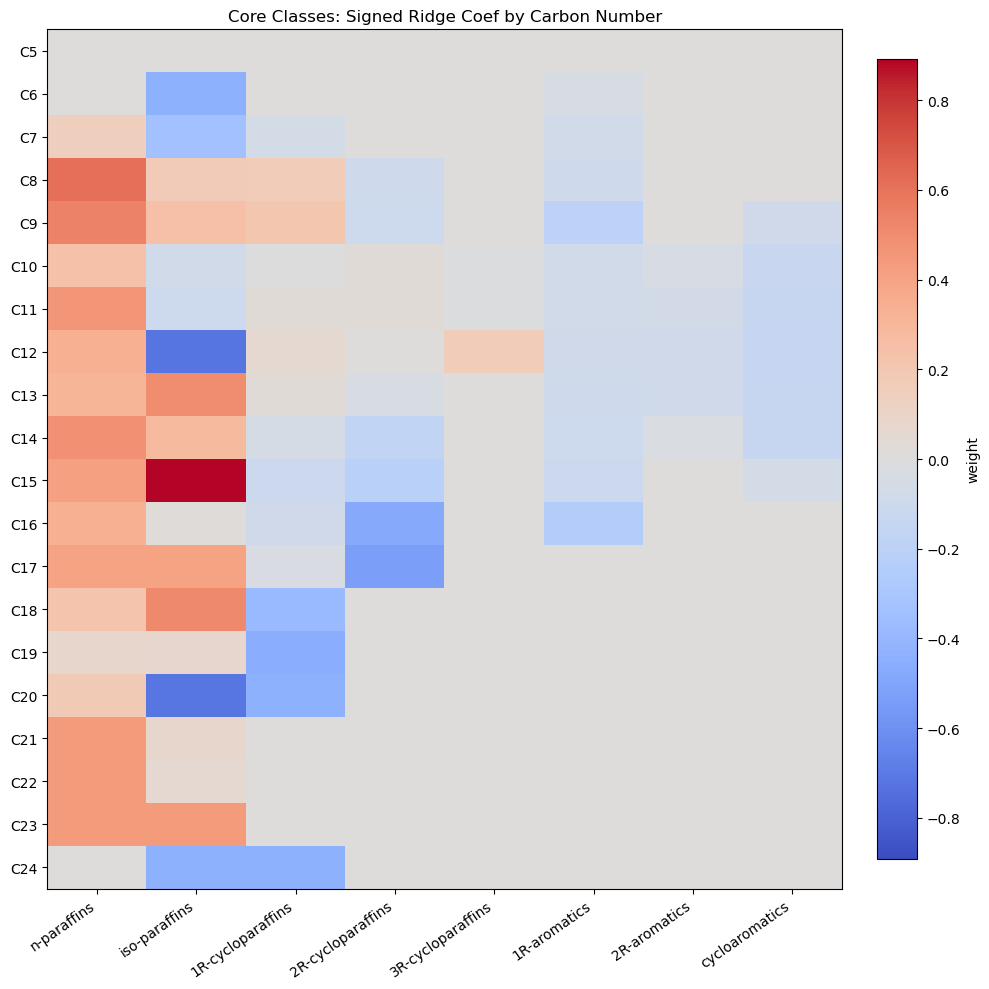

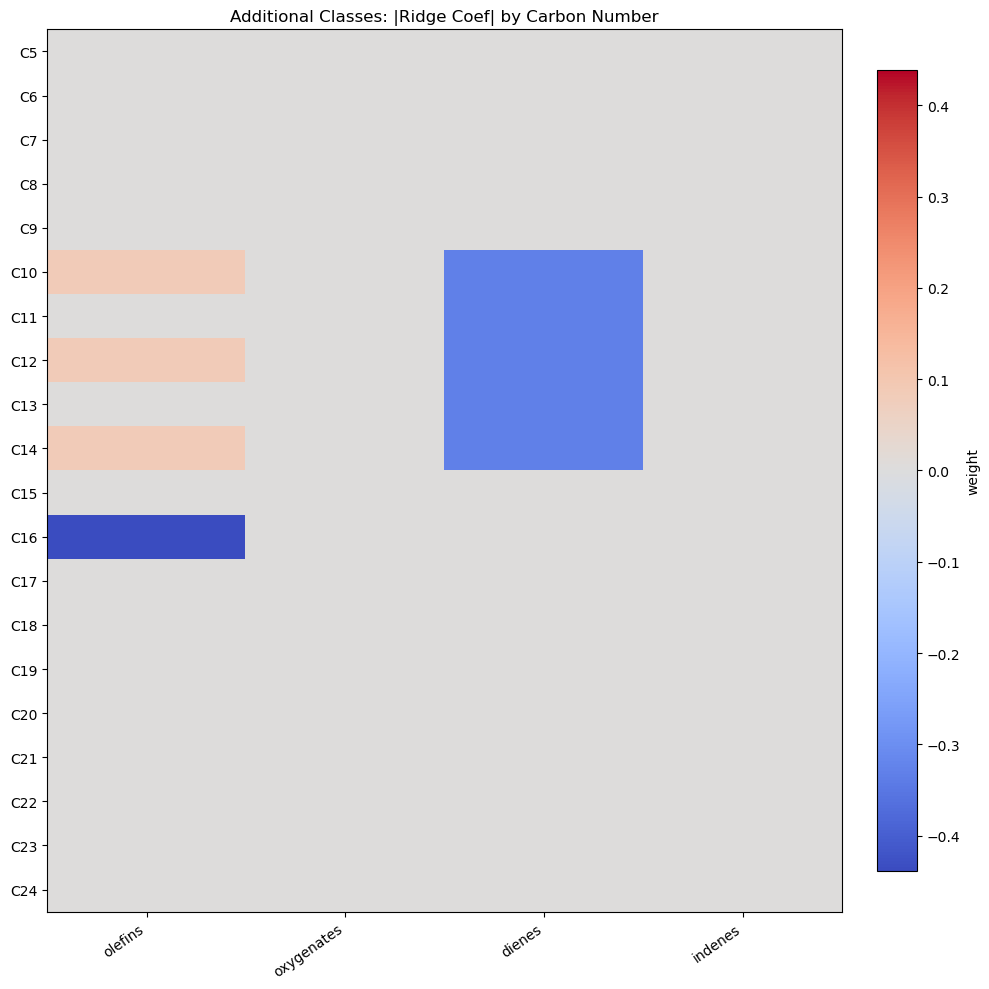

In [22]:
def plot_heatmap(ax, mat, title, cmap='YlOrRd', center=None):
    arr = mat.values
    im = ax.imshow(arr, aspect='auto', cmap=cmap) if center is None else ax.imshow(arr, aspect='auto', cmap=cmap, vmin=-np.max(np.abs(arr)), vmax=np.max(np.abs(arr)))

    ax.set_title(title)
    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=35, ha='right')
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel('weight', rotation=90)

fig, axes = plt.subplots(1, 1, figsize=(10, 10))
plot_heatmap(axes, core_signed_matrix, 'Core Classes: Signed Ridge Coef by Carbon Number', cmap='coolwarm', center=0.0)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(10, 10))
plot_heatmap(axes, extra_signed_matrix, 'Additional Classes: |Ridge Coef| by Carbon Number', cmap='coolwarm', center=0.0)
plt.tight_layout()
plt.show()